Using device: cuda
Sinogram shape : (1000, 513)  [-0.0008, 0.1305]
Ground truth   : (362, 362)   [0.0194, 0.5298]
Reconstruction : (362, 362)  [0.0000, 0.9182]


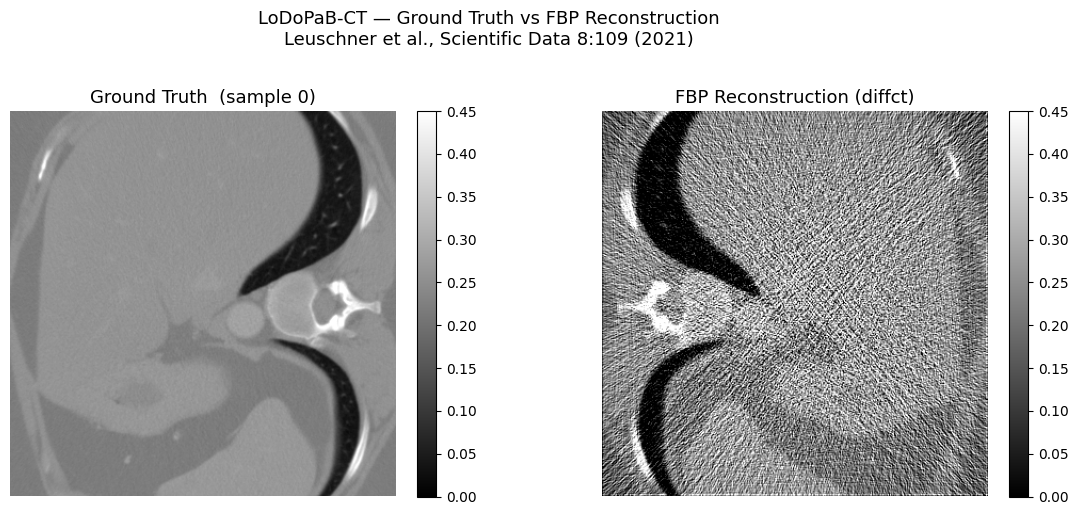

In [ ]:
import sys
import math
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, "..")

from diffct import ParallelBackprojectorFunction, ramp_filter_1d

# ── Config ────────────────────────────────────────────────────────────────────
DATA_PATH  = "../medical_image_datasets/lodopab"
SPLIT      = "test"
SAMPLE_IDX = 0           # change to view a different sample

# Geometry from Leuschner et al. (2021) Scientific Data 8:109
# doi:10.1038/s41597-021-00893-z  (Table in Methods, Fig. 4)
NUM_ANGLES    = 1000
NUM_DETECTORS = 513
IMAGE_SIZE    = 362
DET_SPACING   = IMAGE_SIZE * math.sqrt(2) / NUM_DETECTORS   # ≈ 0.996
VOXEL_SPACING = 1.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Load sample ───────────────────────────────────────────────────────────────
file_idx    = SAMPLE_IDX // 128
idx_in_file = SAMPLE_IDX  % 128

with h5py.File(f"{DATA_PATH}/observation_{SPLIT}_{file_idx:03d}.hdf5",  "r") as f:
    sino_np = f["data"][idx_in_file].astype(np.float32)   # (1000, 513)

with h5py.File(f"{DATA_PATH}/ground_truth_{SPLIT}_{file_idx:03d}.hdf5", "r") as f:
    gt_np   = f["data"][idx_in_file].astype(np.float32)   # (362, 362)

print(f"Sinogram shape : {sino_np.shape}  [{sino_np.min():.4f}, {sino_np.max():.4f}]")
print(f"Ground truth   : {gt_np.shape}   [{gt_np.min():.4f}, {gt_np.max():.4f}]")

# ── FBP reconstruction via diffct ─────────────────────────────────────────────
sino_t = torch.from_numpy(sino_np).to(device)
angles = torch.from_numpy(
    np.linspace(0, math.pi, NUM_ANGLES, endpoint=False).astype(np.float32)
).to(device)

sino_filtered = ramp_filter_1d(sino_t, dim=-1)
with torch.no_grad():
    recon = ParallelBackprojectorFunction.apply(
        sino_filtered, angles, DET_SPACING, IMAGE_SIZE, IMAGE_SIZE, VOXEL_SPACING,
    )

recon_np = np.clip(recon.cpu().numpy(), 0, None)
print(f"Reconstruction : {recon_np.shape}  [{recon_np.min():.4f}, {recon_np.max():.4f}]")

# ── Orientation correction ────────────────────────────────────────────────────
# Per Fig. 4 of Leuschner et al. (2021), the GT is stored transposed
# (line 3: ẑ ← transpose(center_crop(z, 362×362))) to match ODL's (x,y)
# coordinate convention. Transpose back to standard (row=y, col=x) for display.
gt_display = gt_np

# diffct uses y-downward (image) convention; ODL (which generated the sinogram)
# uses y-upward (math) convention → the backprojection is flipped vertically.
recon_display = recon_np

# ── Side-by-side visualisation ────────────────────────────────────────────────
# Window [0, 0.45] matches Fig. 5 of the paper (≈ HU range [-1001, 831])
vmin, vmax = 0.0, 0.45

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(gt_display,    cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title(f"Ground Truth  (sample {SAMPLE_IDX})", fontsize=13)
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(recon_display, cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title("FBP Reconstruction (diffct)", fontsize=13)
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle("LoDoPaB-CT — Ground Truth vs FBP Reconstruction\n"
             "Leuschner et al., Scientific Data 8:109 (2021)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


PSNR: 18.99 dB
SSIM: 0.1975


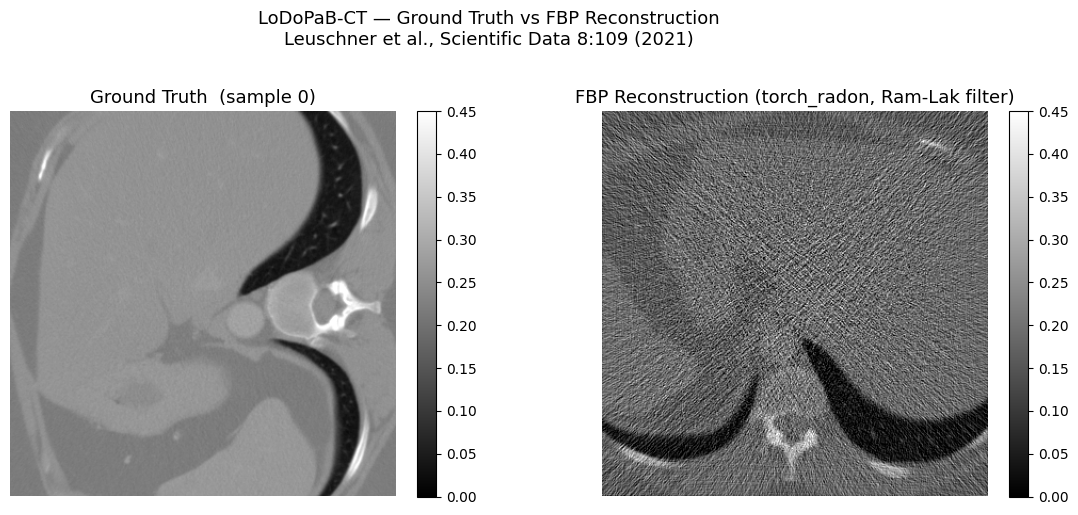

In [ ]:
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, "..")

from utils.lodopab_dataset import LoDoPaBDataset
from sinogram_trainer.parallel_fbp import DifferentiableParallelFBP
from utils.metrics import compute_psnr, compute_ssim, compute_rmse

# ── Config ────────────────────────────────────────────────────────────────────
SAMPLE_IDX = 0           # change to view a different sample

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Load sample via LoDoPaBDataset ────────────────────────────────────────────
ds = LoDoPaBDataset(mode="test")
sino_t, gt_t = ds[SAMPLE_IDX]          # (1, 1000, 513), (1, 362, 362)

sino_t = sino_t.unsqueeze(0).to(device)   # (1, 1, 1000, 513)
gt_np  = gt_t.squeeze().numpy()           # (362, 362)

# ── FBP reconstruction via torch_radon (Ram-Lak filter) ──────────────────────
fbp = DifferentiableParallelFBP.from_lodopab().to(device)

with torch.no_grad():
    recon_t = fbp(sino_t)                 # (1, 1, 362, 362)

recon_np = recon_t.squeeze().cpu().numpy()

# ── Orientation correction ────────────────────────────────────────────────────
# GT is stored transposed (ODL x-y convention, Fig. 4 Leuschner et al. 2021)
gt_display    = gt_np
# flipud is now applied inside DifferentiableParallelFBP.forward — no extra transform needed
recon_display = recon_np

# ── Side-by-side visualisation ────────────────────────────────────────────────
vmin, vmax = 0.0, 0.45

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

psnr = compute_psnr(gt_display, recon_display)
ssim = compute_ssim(gt_display, recon_display)
print(f"PSNR: {psnr:.2f} dB")
print(f"SSIM: {ssim:.4f}")

im0 = axes[0].imshow(gt_display,    cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title(f"Ground Truth  (sample {SAMPLE_IDX})", fontsize=13)
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(recon_display, cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title("FBP Reconstruction (torch_radon, Ram-Lak filter)", fontsize=13)
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle("LoDoPaB-CT — Ground Truth vs FBP Reconstruction\n"
             "Leuschner et al., Scientific Data 8:109 (2021)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
